In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

In [2]:
data2010= pd.read_csv(f'../hw3/data/data-2010.csv') 
data2011= pd.read_csv(f'../hw3/data/data-2011.csv')
data2012= pd.read_csv(f'../hw3/data/data-2012.csv')
data2013= pd.read_csv(f'../hw3/data/data-2013.csv')
data2014= pd.read_csv(f'../hw3/data/data-2014.csv')
data2015= pd.read_csv(f'../hw3/data/data-2015.csv')

In [3]:
#merge years
years = range(2010, 2016)
dfs = []
for year in years:
    df = pd.read_csv(f'../hw3/data/data-{year}.csv')
    dfs.append(df)

# Concatenate into one DataFrame
data = pd.concat(dfs, ignore_index=True)

### Question 1

In [4]:
# Market share = average enrolled / average eligibles (from penetration merge)
data["market_share"] = data["avg_enrolled"] / data["avg_eligibles"]

summary = (
    data.groupby("year")
    .agg(
        mean_star_rating  = ("Star_Rating",    "mean"),
        mean_enrollment   = ("avg_enrollment", "mean"),
        mean_market_share = ("market_share",   "mean"),
        n_plans           = ("contractid",     "count"),
    )
    .reset_index()
    .rename(columns={"year": "Year"})
)

# Format for display
summary["mean_star_rating"]  = summary["mean_star_rating"].round(2)
summary["mean_enrollment"]   = summary["mean_enrollment"].round(0).astype(int)
summary["mean_market_share"] = (summary["mean_market_share"] * 100).round(2).astype(str) + "%"

summary.columns = ["Year", "Mean Star Rating", "Mean Enrollment", "Mean Market Share (%)", "N Plans"]
summary = summary.set_index("Year")

print(summary.to_string())
print()

      Mean Star Rating  Mean Enrollment Mean Market Share (%)  N Plans
Year                                                                  
2010              2.97              256                20.76%   108222
2011              3.28              343                21.44%    68003
2012              3.42              377                23.49%    67246
2013              3.54              396                25.63%    67835
2014              3.70              437                28.39%    62344
2015              3.96              470                29.76%    65499



### Question 2

In [5]:
no_star = data[data["Star_Rating"].isna()]

summary_no_star = (
    no_star.groupby("year")
    .agg(
        mean_enrollment   = ("avg_enrollment", "mean"),
        mean_market_share = ("market_share",   "mean"),
        n_plans           = ("contractid",     "count"),
    )
    .reset_index()
    .rename(columns={"year": "Year"})
)

summary_no_star["mean_enrollment"]   = summary_no_star["mean_enrollment"].round(0).astype(int)
summary_no_star["mean_market_share"] = (summary_no_star["mean_market_share"] * 100).round(2).astype(str) + "%"

summary_no_star.columns = ["Year", "Mean Enrollment", "Mean Market Share (%)", "N Plans (No Star Rating)"]
summary_no_star = summary_no_star.set_index("Year")

print(summary_no_star.to_string())

      Mean Enrollment Mean Market Share (%)  N Plans (No Star Rating)
Year                                                                 
2010              107                19.42%                     48643
2011              168                22.45%                     12754
2012              157                25.73%                      8728
2013              162                27.76%                      3245
2014              228                28.73%                      3787
2015              314                28.17%                      4680


### Question 3

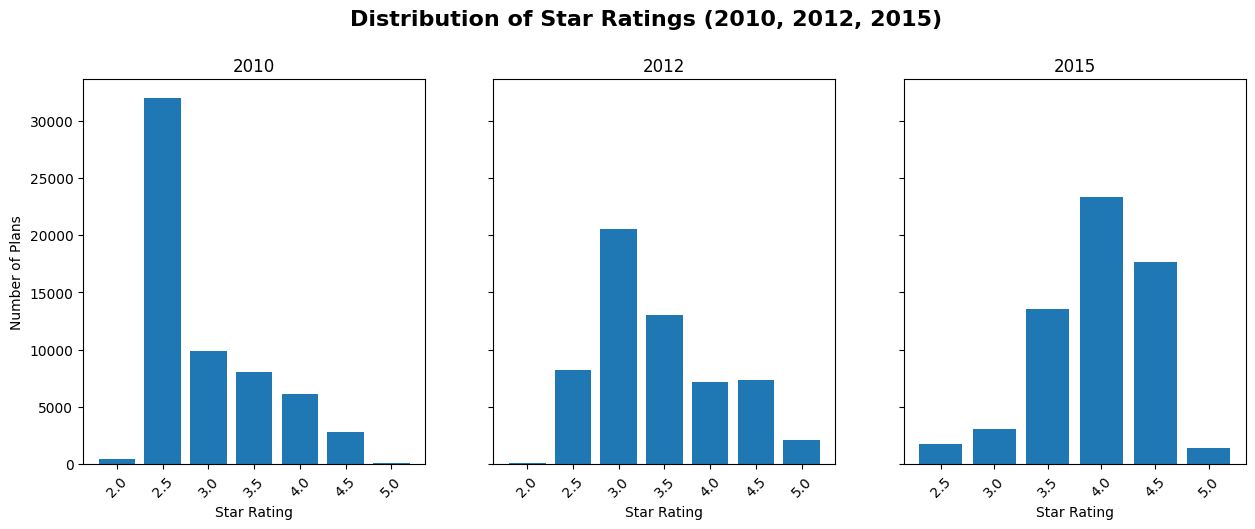

In [6]:
years = [2010, 2012, 2015]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, year in zip(axes, years):
    df_year = data[data["year"] == year]
    
    star_counts = (
        df_year["Star_Rating"]
        .dropna()
        .value_counts()
        .sort_index()
    )
    
    ax.bar(star_counts.index.astype(str), star_counts.values)
    
    ax.set_title(f"{year}", )
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Number of Plans" if year == 2010 else "")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Distribution of Star Ratings (2010, 2012, 2015)", 
             fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
plt.show()

Interpretation: In 2010, a large proportion of plans concentrated aroudn a star rating of 2.5, and over time, the distribution has normalized and shifted right. In 2012, the largest concentration of star ratings was 3. In 2015, there were no star ratings below 2.5, unlike previously, and we see that the largest concentration of rating scores was 4. This could tell us that either the overall quality of each plan has increased, or that insurance companies have figured out how to game the rating system to have their plans appear higher quality than they may actually be.

### Question 4

In [7]:
YEARS = range(2010, 2016)

def run_ols(df):
    temp = df[["market_share", "Star_Rating"]].dropna()
    
    # Create indicator variables (excluded: <= 2.5)
    temp["star_3"]   = (temp["Star_Rating"] == 3.0).astype(int)
    temp["star_35"]  = (temp["Star_Rating"] == 3.5).astype(int)
    temp["star_4"]   = (temp["Star_Rating"] == 4.0).astype(int)
    temp["star_45"]  = (temp["Star_Rating"] >= 4.5).astype(int)
    
    X = temp[["star_3", "star_35", "star_4", "star_45"]].values
    X = np.column_stack([np.ones(len(X)), X])  # add intercept
    y = temp["market_share"].values
    
    # OLS estimates
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    
    # Standard errors
    y_hat = X @ beta
    resid = y - y_hat
    n, k = X.shape
    s2 = (resid @ resid) / (n - k)
    var_beta = s2 * XtX_inv
    se = np.sqrt(np.diag(var_beta))
    
    # T-stats and p-values
    t_stats = beta / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
    
    return beta, se, p_values, n

# Run for each year
results = {}
for year in YEARS:
    df_year = data[data["year"] == year]
    beta, se, p_values, n = run_ols(df_year)
    results[year] = {"beta": beta, "se": se, "p_values": p_values, "n": n}

# Build table
labels = ["Intercept", "Star 3", "Star 3.5", "Star 4", "Star 4.5+"]

def stars(p):
    if p < 0.01:  return "***"
    elif p < 0.05: return "**"
    elif p < 0.1:  return "*"
    return ""

rows = []
for i, label in enumerate(labels):
    # Coefficient row
    coef_row = {"Variable": label}
    for year in YEARS:
        b = results[year]["beta"][i]
        p = results[year]["p_values"][i]
        coef_row[str(year)] = f"{b:.4f}{stars(p)}"
    rows.append(coef_row)
    
    # Standard error row
    se_row = {"Variable": ""}
    for year in YEARS:
        se = results[year]["se"][i]
        se_row[str(year)] = f"({se:.4f})"
    rows.append(se_row)

# Add N row
n_row = {"Variable": "N"}
for year in YEARS:
    n_row[str(year)] = str(results[year]["n"])
rows.append(n_row)

table = pd.DataFrame(rows).set_index("Variable")
table

,2010,2011,2012,2013,2014,2015
Variable,,,,,,
Intercept,0.1889***,0.1931***,0.1552***,0.1775***,0.2458***,0.2716***
,(0.0007),(0.0012),(0.0015),(0.0016),(0.0030),(0.0033)
Star 3,0.0583***,-0.0121***,0.0492***,0.0573***,0.0128***,0.0166***
,(0.0015),(0.0015),(0.0017),(0.0020),(0.0034),(0.0042)
Star 3.5,0.0640***,0.0330***,0.0994***,0.0750***,0.0264***,0.0185***
,(0.0016),(0.0018),(0.0019),(0.0018),(0.0031),(0.0035)
Star 4,0.0470***,0.0728***,0.1481***,0.1042***,0.0473***,0.0242***
,(0.0018),(0.0019),(0.0022),(0.0020),(0.0032),(0.0035)
Star 4.5+,0.1276***,0.0573***,0.1159***,0.1429***,0.0811***,0.0416***


### Question 5

In [31]:
measure_cols = [
    'breastcancer_screen', 'rectalcancer_screen', 'cv_diab_cholscreen',
    'glaucoma_test', 'monitoring', 'flu_vaccine', 'pn_vaccine',
    'physical_health', 'mental_health', 'osteo_test', 'physical_monitor',
    'primaryaccess', 'osteo_manage', 'diab_healthy', 'bloodpressure',
    'ra_manage', 'copd_test', 'bladder', 'falling', 'nodelays',
    'doctor_communicate', 'carequickly', 'customer_service',
    'overallrating_care', 'overallrating_plan', 'complaints_plan',
    'appeals_timely', 'appeals_review', 'leave_plan', 'audit_problems',
    'hold_times', 'info_accuracy', 'ttyt_available'
]

data2010["raw_rating"] = data2010[measure_cols].mean(axis=1, skipna=True)

print("Non-null raw_rating:", data2010["raw_rating"].notna().sum())
print("raw_rating range:", data2010["raw_rating"].min(), "to", data2010["raw_rating"].max())
print("Sample values:", data2010["raw_rating"].dropna().head(10).values)

Non-null raw_rating: 93892
raw_rating range: 1.6666666666666667 to 5.0
Sample values: [3.10714286 3.10714286 3.10714286 3.10714286 3.10714286 3.10714286
 3.10714286 3.10714286 3.10714286 3.10714286]


In [32]:
results = []

for star, low, high, midpoint in [
    (3.0, 2.75, 3.25, 2.75),
    (3.5, 3.25, 3.75, 3.25),
    (4.0, 3.75, 4.25, 3.75),
    (4.5, 4.25, 4.75, 4.25),
    (5.0, 4.75, 5.25, 4.75),
]:
    prev_star = star - 0.5

    # plans with this star rating and non-missing partc_score
    candidates_mask = (
        data2010["raw_rating"].notna()
        & data2010["Star_Rating"].notna()
        & data2010["Star_Rating"].isin([prev_star, star])
    )
    candidates = data2010.loc[candidates_mask].copy()

    # score rounding
    match_mask = (
        candidates["raw_rating"].between(low, high)
        & (
            ((candidates["Star_Rating"] == star) &
             (candidates["raw_rating"] >= midpoint))
            |
            ((candidates["Star_Rating"] == prev_star) &
             (candidates["raw_rating"] <= midpoint))
        )
    )
    rounded_up = candidates.loc[match_mask]
    n_rounded_up = len(rounded_up[rounded_up["Star_Rating"] == star])

    print(f"\nStar Rating: {star}")
    print(f"  Candidates (partc_score non-missing): {len(candidates)}")
    print(f"  Plans rounded up into {star} stars:  {n_rounded_up}")

    results.append({"Star Rating": star, "N Plans Rounded Up": n_rounded_up})


Star Rating: 3.0
  Candidates (partc_score non-missing): 41917
  Plans rounded up into 3.0 stars:  9918

Star Rating: 3.5
  Candidates (partc_score non-missing): 18009
  Plans rounded up into 3.5 stars:  8091

Star Rating: 4.0
  Candidates (partc_score non-missing): 14258
  Plans rounded up into 4.0 stars:  4284

Star Rating: 4.5
  Candidates (partc_score non-missing): 8998
  Plans rounded up into 4.5 stars:  771

Star Rating: 5.0
  Candidates (partc_score non-missing): 2933
  Plans rounded up into 5.0 stars:  30


### Question 6

In [33]:
data2010["market_share"] = data2010["avg_enrolled"] / data2010["avg_eligibles"]
bw = 0.125
def sig_stars(p):
    if p < 0.01:   return "***"
    elif p < 0.05: return "**"
    elif p < 0.1:  return "*"
    return ""
all_results = {}

for star, midpoint, label in [
    (3.0, 2.75, "3-star vs 2.5-star"),
    (3.5, 3.25, "3.5-star vs 3-star"),
]:
    prev_star = star - 0.5

    candidates_mask = (
        data2010["raw_rating"].notna()
        & data2010["Star_Rating"].notna()
        & data2010["Star_Rating"].isin([prev_star, star])
    )
    ma_rd = data2010.loc[candidates_mask].copy()

    # Running variable and treatment indicator
    ma_rd["score"]       = ma_rd["raw_rating"] - midpoint
    ma_rd["treat"]       = (ma_rd["score"] >= 0).astype(int)
    ma_rd["score_treat"] = ma_rd["score"] * ma_rd["treat"]
    ma_rd["window1"]     = ma_rd["score"].between(-0.175, 0.175)
    ma_rd["window2"]     = ma_rd["score"].between(-bw, bw)

    # specifications
    m1 = smf.ols("avg_enrollment ~ score + treat",
                 data=ma_rd).fit()
    m2 = smf.ols("avg_enrollment ~ score + treat",
                 data=ma_rd[ma_rd["window1"]]).fit()
    m3 = smf.ols("avg_enrollment ~ score + treat + score_treat",
                 data=ma_rd[ma_rd["window1"]]).fit()
    m4 = smf.ols("avg_enrollment ~ score + treat + score_treat",
                 data=ma_rd[ma_rd["window2"]]).fit()

    est1 = float(m1.params["treat"])
    est2 = float(m2.params["treat"])
    est3 = float(m3.params["treat"])
    est4 = float(m4.params["treat"])

    se1 = float(m1.bse["treat"])
    se2 = float(m2.bse["treat"])
    se3 = float(m3.bse["treat"])
    se4 = float(m4.bse["treat"])

    all_results[label] = {
        "ests": [est1, est2, est3, est4],
        "ses":  [se1,  se2,  se3,  se4],
    }

    print(f"\n{'='*55}")
    print(f"RD Estimates: {label}")
    print(f"{'='*55}")
    for i, (est, se, bw_label) in enumerate(zip(
        [est1, est2, est3, est4],
        [se1,  se2,  se3,  se4],
        ["Full", "0.175", "0.175+interact", "0.125+interact"]
    )):
        p = 2 * (1 - stats.t.cdf(abs(est / se), df=m1.df_resid))
        print(f"  Model {i+1} ({bw_label}): {est:.2f}{sig_stars(p)}  SE={se:.2f}")

# Summary table
rows = pd.DataFrame({
    "term":      ["Bandwidth"],
    "m1":        ["Full"],
    "m2":        ["0.175"],
    "m3":        ["0.175"],
    "m4":        ["0.125"],
})
rows.attrs["position"] = 7
print("\nBandwidth row:")
print(rows)


RD Estimates: 3-star vs 2.5-star
  Model 1 (Full): 389.82***  SE=51.03
  Model 2 (0.175): 427.21***  SE=57.52
  Model 3 (0.175+interact): 503.28***  SE=64.27
  Model 4 (0.125+interact): 226.15***  SE=72.68

RD Estimates: 3.5-star vs 3-star
  Model 1 (Full): -549.81***  SE=91.77
  Model 2 (0.175): -407.15**  SE=174.40
  Model 3 (0.175+interact): -298.28  SE=181.93
  Model 4 (0.125+interact): -245.30  SE=176.96

Bandwidth row:
        term    m1     m2     m3     m4
0  Bandwidth  Full  0.175  0.175  0.125


### Question 7

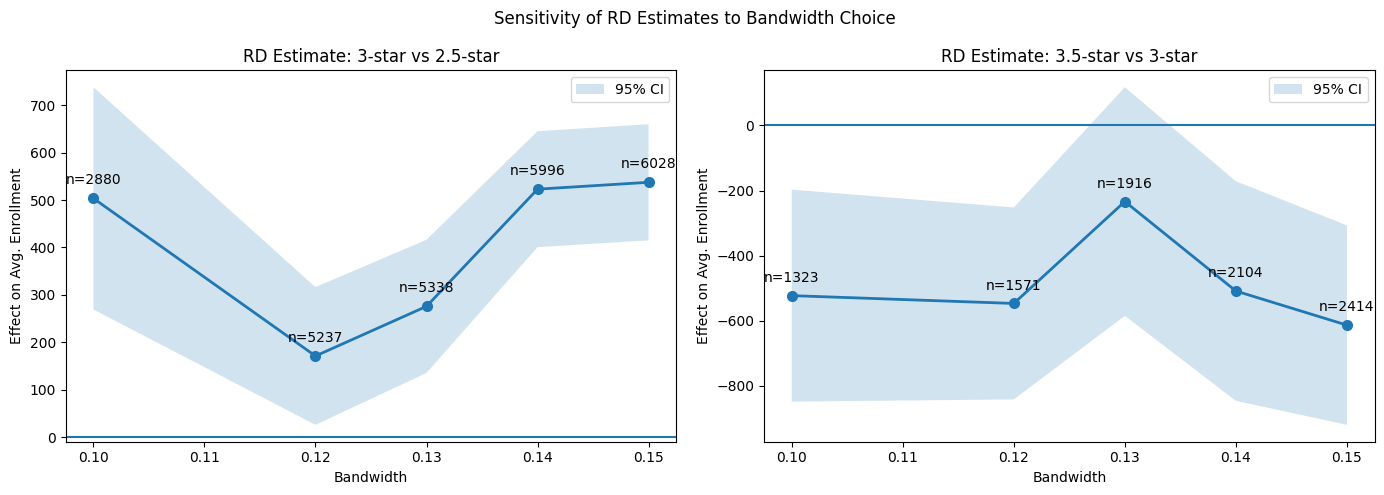

In [29]:
bws = [0.10, 0.12, 0.13, 0.14, 0.15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (star, midpoint, label) in zip(axes, [
    (3.0, 2.75, "3-star vs 2.5-star"),
    (3.5, 3.25, "3.5-star vs 3-star"),
]):
    prev_star = star - 0.5
    candidates = data2010[data2010["Star_Rating"].isin([prev_star, star])].copy()
    candidates["score"]       = candidates["raw_rating"] - midpoint
    candidates["treat"]       = (candidates["score"] >= 0).astype(int)
    candidates["score_treat"] = candidates["score"] * candidates["treat"]
    candidates = candidates.dropna(subset=["avg_enrollment", "score"])

    coefs, ses = [], []
    for bw in bws:
        window = candidates["score"].between(-bw, bw)
        sample = candidates[window]
        if len(sample) < 10:
            coefs.append(np.nan)
            ses.append(np.nan)
            continue
        m = smf.ols("avg_enrollment ~ score + treat + score_treat",
                    data=sample).fit()
        coefs.append(float(m.params["treat"]))
        ses.append(float(m.bse["treat"]))

    coefs = np.array(coefs)
    ses   = np.array(ses)

    ax.plot(bws, coefs, 'o-', linewidth=2, markersize=7)
    ax.fill_between(bws,
                    coefs - 1.96 * ses,
                    coefs + 1.96 * ses,
                    alpha=0.2, label="95% CI")
    ax.axhline(0)
    ax.set_title(f"RD Estimate: {label}")
    ax.set_xlabel("Bandwidth")
    ax.set_ylabel("Effect on Avg. Enrollment")
    ax.legend()

    for bw, coef, n in zip(bws, coefs,
                           [candidates["score"].between(-b, b).sum() for b in bws]):
        ax.annotate(f"n={n}", (bw, coef),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center')

fig.suptitle("Sensitivity of RD Estimates to Bandwidth Choice")
plt.tight_layout()
plt.show()

Interpretation: 

### Question 8

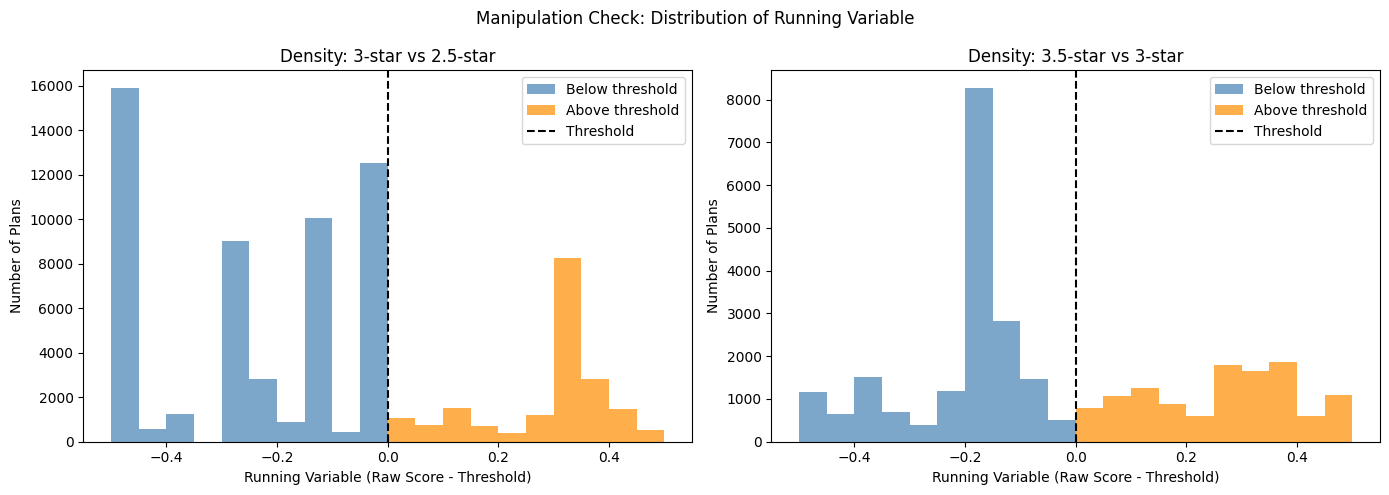

In [38]:
thresholds = {
    "3-star vs 2.5-star": 2.75,
    "3.5-star vs 3-star": 3.25,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, thresh) in zip(axes, thresholds.items()):
    bw = 0.5
    temp = data2010.copy()
    temp["score"] = temp["raw_rating"] - thresh
    temp = temp[(temp["score"] >= -bw) & (temp["score"] <= bw)].dropna(subset=["score"])

    bins = np.arange(-bw, bw + 0.05, 0.05)
    below = temp[temp["score"] < 0]["score"]
    above = temp[temp["score"] >= 0]["score"]

    ax.hist(below, bins=bins, color="steelblue", alpha=0.7, label="Below threshold")
    ax.hist(above, bins=bins, color="darkorange", alpha=0.7, label="Above threshold")
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label="Threshold")
    ax.set_title(f"Density: {label}")
    ax.set_xlabel("Running Variable (Raw Score - Threshold)")
    ax.set_ylabel("Number of Plans")
    ax.legend()

fig.suptitle("Manipulation Check: Distribution of Running Variable")
plt.tight_layout()
plt.show()

### Question 9

In [41]:
data2010["is_hmo"]  = (data2010["plan_type"].str.upper().str.contains("HMO|CCP|LOCAL", na=False)).astype(int)
data2010["is_partd"] = (data2010["partd"] == "Yes").astype(int)

print("\n" + "=" * 60)
print("Table 3: Covariate Balance Around Thresholds (Bandwidth=0.125)")
print("=" * 60)

bw = 0.125
balance_rows = []

for label, thresh in thresholds.items():
    temp = data2010.copy()
    temp["score"] = temp["raw_rating"] - thresh
    temp = temp[(temp["score"] >= -bw) & (temp["score"] <= bw)].dropna(subset=["score"])
    
    below = temp[temp["score"] < 0]
    above = temp[temp["score"] >= 0]

    for covariate in ["is_hmo", "is_partd"]:
        mean_below = below[covariate].mean()
        mean_above = above[covariate].mean()
        diff = mean_above - mean_below
        
        # T-test for difference
        t, p = stats.ttest_ind(above[covariate], below[covariate])
        
        balance_rows.append({
            "Threshold":   label,
            "Covariate":   "HMO" if covariate == "is_hmo" else "Part D",
            "Mean Below":  f"{mean_below:.3f}",
            "Mean Above":  f"{mean_above:.3f}",
            "Difference":  f"{diff:.3f}{sig_stars(p)}",
            "P-value":     f"{p:.3f}",
            "N Below":     len(below),
            "N Above":     len(above),
        })

balance_table = pd.DataFrame(balance_rows)
print(balance_table.to_string(index=False))


Table 3: Covariate Balance Around Thresholds (Bandwidth=0.125)
         Threshold Covariate Mean Below Mean Above Difference P-value  N Below  N Above
3-star vs 2.5-star       HMO      0.032      0.596   0.564***   0.000    22385     2528
3-star vs 2.5-star    Part D      0.549      0.840   0.291***   0.000    22385     2528
3.5-star vs 3-star       HMO      0.788      0.848   0.060***   0.000     3969     2452
3.5-star vs 3-star    Part D      0.864      0.817  -0.047***   0.000     3969     2452


### Question 10

Summarize your findings from 5-9. What is the effect of increasing a star rating on enrollments? Briefly explain your results